# Fase 2 — Transformação dos Dados no Dataset
---

## Objetivo 

Identificar colunas que precisam de alterações

- Resolver colunas numéricas divididas em intervalos
- Tratar colunas com valores nulos em classifições
- Partir de colunas categóricas para valores numéricos
- Analisar interferência dos outliers
- Avaliar colunas com baixa variância
- Resolver colunas que são valores compostos (listas)
- Usar a coluna do CNAE para melhor identificação
- Criar colunas derivadas a partir de dados dos clientes: Feature engineering
- Padronizar/normalizar variáveis numéricas quando necessário
- Separar treino/teste antes de transformações críticas


---

## Datasets disponíveis

| Arquivo | Descrição |
|---|---|
| `credito_aplicacao_clientes.csv` | Dados cadastrais de 200 clientes (Serasa, iFood, Google Maps, etc.) |
| `credito_comportamental_pedidos.csv` | Histórico de 200 pedidos de clientes já ativos |

## 0. Importações

- `pandas`: manipulação e análise de dados tabulares
- `numpy`: operações numéricas
- `os`: Escrever arquivo csv a partir do df

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import os
import re
print("Importações Concluídas")

Importações Concluídas


## 1. Carregando os Dados

### 1.1 Importando os CSVs

In [43]:
# Carregamento dos dois datasets
df_clientes = pd.read_csv('../dados/Brutos/credito_aplicacao_clientes.csv', sep=',')
df_pedidos  = pd.read_csv('../dados/Brutos/credito_comportamental_pedidos.csv', sep=',')

print('Datasets carregados')
print(f'  Clientes: {df_clientes.shape[0]} linhas x {df_clientes.shape[1]} colunas')
print(f'  Pedidos:  {df_pedidos.shape[0]} linhas x {df_pedidos.shape[1]} colunas')

Datasets carregados
  Clientes: 200 linhas x 20 colunas
  Pedidos:  200 linhas x 5 colunas


In [44]:
df_clientes.head()

,id_cliente,uf,municipio,segmento_cliente,natureza_juridica,fonte_cliente,cnae_codigo,cnae_descricao,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_credores,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,ifood_faixa_preco,google_maps_avaliacao,google_maps_contagem_avaliacoes,google_maps_tem_website,inadimplente
0,5649308221613,PE,RECIFE,Restaurante Brasileiro,230-5 - Empresa Individual de Responsabilidade...,Fonte 5,56.11-2-01,Restaurantes e similares,"(100000, 200000]","(8000, 25000]",0.0,0.0,NaN,0.0,"(200, 500]",$$$$$,"(4.0, 4.5]","(1000, 2500]",1.0,0.0
1,5728626180269,PE,RECIFE,Padaria,230-5 - Empresa Individual de Responsabilidade...,Fonte 5,10.91-1-02,Fabricação de produtos de padaria e confeitari...,"(70000, 100000]","(8000, 25000]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
2,5740206260397,PE,JABOATAO DOS GUARARAPES,Conveniência,206-2 - Sociedade Empresária Limitada,Fonte 5,46.13-3-00,Representantes comerciais e agentes do comérci...,"(8000, 10000]","(5000, 8000]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
3,5741028343981,PE,FERNANDO DE NORONHA,Hotel,206-2 - Sociedade Empresária Limitada,Fonte 5,55.10-8-01,Hotéis,"(8000, 10000]","(5000, 8000]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
4,5741479985325,PE,RECIFE,Churrascaria,206-2 - Sociedade Empresária Limitada,Fonte 5,56.11-2-01,Restaurantes e similares,"(200000, 1000000]","(8000, 25000]",0.0,0.0,NaN,0.0,"(50, 100]",$,"(4.0, 4.5]","(30, 50]",1.0,0.0


In [45]:
df_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       200 non-null    int64  
 1   uf                               200 non-null    str    
 2   municipio                        200 non-null    str    
 3   segmento_cliente                 200 non-null    str    
 4   natureza_juridica                200 non-null    str    
 5   fonte_cliente                    200 non-null    str    
 6   cnae_codigo                      200 non-null    str    
 7   cnae_descricao                   200 non-null    str    
 8   capital_social                   200 non-null    str    
 9   idade_cnpj                       200 non-null    str    
 10  serasa_contagem_negativacoes     200 non-null    float64
 11  serasa_contagem_protestos        200 non-null    float64
 12  serasa_credores                  

In [46]:
df_pedidos.head()

,id_pedido,id_cliente,valor,atraso,data_entrega
0,6257585946797,5594576584877,239.06,0.0,2025-08-04
1,6258000789677,5594576584877,273.12,0.0,2025-08-04
2,6262535717037,5594576584877,253.45,0.0,2025-08-07
3,6262547972269,5594576584877,246.76,7.0,2025-08-07
4,6264005820589,5594576584877,147.96,3.0,2025-08-08


In [47]:
df_clientes_tratado = df_clientes.copy() #criando uma cópia do dataframe original para tratamento
df_pedidos_tratado  = df_pedidos.copy()

In [48]:
df_clientes_tratado.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       200 non-null    int64  
 1   uf                               200 non-null    str    
 2   municipio                        200 non-null    str    
 3   segmento_cliente                 200 non-null    str    
 4   natureza_juridica                200 non-null    str    
 5   fonte_cliente                    200 non-null    str    
 6   cnae_codigo                      200 non-null    str    
 7   cnae_descricao                   200 non-null    str    
 8   capital_social                   200 non-null    str    
 9   idade_cnpj                       200 non-null    str    
 10  serasa_contagem_negativacoes     200 non-null    float64
 11  serasa_contagem_protestos        200 non-null    float64
 12  serasa_credores                  

### 1.2 Merge com Dados de Pedidos
Os dados do dataset de pedidos possuem informações importantes sobre o comportamento de pagamento dos clientes. Vamos criar features agregadas por cliente a partir de `df_pedidos`.

In [49]:
# Agregações por cliente a partir do histórico de pedidos
agg_pedidos = df_pedidos_tratado.groupby('id_cliente').agg(
    qtd_pedidos=('id_pedido', 'count'),
    valor_total_pedidos=('valor', 'sum'),
    valor_medio_pedido=('valor', 'mean'),
    valor_max_pedido=('valor', 'max'),
    atraso_total=('atraso', 'sum'),
    atraso_medio=('atraso', 'mean'),
    atraso_max=('atraso', 'max'),
    pedidos_com_atraso=('atraso', lambda x: (x > 0).sum()),
).reset_index()

# Taxa de atraso: proporção de pedidos com atraso
agg_pedidos['taxa_atraso'] = (
    agg_pedidos['pedidos_com_atraso'] / agg_pedidos['qtd_pedidos']
).round(4)

print('Agregações criadas:')
print(agg_pedidos.columns.tolist())
print(f'\nClientes com histórico de pedidos: {len(agg_pedidos)}')
agg_pedidos.head()

Agregações criadas:
['id_cliente', 'qtd_pedidos', 'valor_total_pedidos', 'valor_medio_pedido', 'valor_max_pedido', 'atraso_total', 'atraso_medio', 'atraso_max', 'pedidos_com_atraso', 'taxa_atraso']

Clientes com histórico de pedidos: 20


,id_cliente,qtd_pedidos,valor_total_pedidos,valor_medio_pedido,valor_max_pedido,atraso_total,atraso_medio,atraso_max,pedidos_com_atraso,taxa_atraso
0,5594576584877,31,9421.22,303.910323,843.14,25.0,0.806452,7.0,9,0.2903
1,5596566126765,5,4662.07,932.414000,1247.44,4.0,0.800000,2.0,2,0.4000
2,5597230563501,2,3243.90,1621.950000,2065.10,3.0,1.500000,3.0,1,0.5000
3,5649308221613,13,11755.37,904.259231,2263.00,2.0,0.153846,2.0,1,0.0769
4,5653426667693,4,3257.19,814.297500,2147.55,1.0,0.250000,1.0,1,0.2500


In [50]:
# Merge left: mantém todos os clientes, preenche com 0 quem não tem pedidos
df_clientes_tratado = df_clientes_tratado.merge(
    agg_pedidos,
    on='id_cliente',
    how='left'
)

colunas_pedido = agg_pedidos.columns.drop('id_cliente').tolist()
df_clientes_tratado[colunas_pedido] = df_clientes_tratado[colunas_pedido].fillna(0)

print(f'Shape após merge: {df_clientes_tratado.shape}')
print(f'Clientes sem histórico de pedidos (qtd_pedidos == 0): {(df_clientes_tratado["qtd_pedidos"] == 0).sum()}')

Shape após merge: (200, 29)
Clientes sem histórico de pedidos (qtd_pedidos == 0): 197


## 2. Tratamento de Dados Brutos

Esta seção é responsável pelo tratamento do dataset para uma versão sem os problemas de campos nulos e intervalos, onde não há risco de vazamento de dados e os métodos podem ser aplicados na base inteira como um todo.

### 2.1 Resolução de colunas numéricas divididas em Intervalos


#### 2.1.1 Identificação de Intervalos

In [51]:
# Padrão exato de intervalo numérico, ex.: (1000, 2500] ou [0, 5)
padrao_intervalo = re.compile(r"^\s*[\(\[]\s*-?\d+(?:[\.,]\d+)?\s*,\s*-?\d+(?:[\.,]\d+)?\s*[\)\]]\s*$")

colunas_intervalo = []

for coluna in df_clientes.columns:
    serie = df_clientes[coluna].dropna().astype(str).str.strip()
    if serie.empty:
        continue

    # Considera coluna de intervalo quando todos os valores não nulos seguem o padrão
    if serie.str.match(padrao_intervalo).all():
        colunas_intervalo.append(coluna)
        exemplos = serie.drop_duplicates().head(3).tolist()
        print(f"{coluna}: {exemplos}")

if not colunas_intervalo:
    print("Nenhuma coluna com padrão de intervalo foi encontrada.")
else:
    print("\nColunas identificadas:", colunas_intervalo)

capital_social: ['(100000, 200000]', '(70000, 100000]', '(8000, 10000]']
idade_cnpj: ['(8000, 25000]', '(5000, 8000]', '(4000, 5000]']
ifood_contagem_avaliacoes: ['(200, 500]', '(50, 100]', '(5, 10]']
google_maps_avaliacao: ['(4.0, 4.5]', '(4.5, 5.0]', '(3.0, 4.0]']
google_maps_contagem_avaliacoes: ['(1000, 2500]', '(30, 50]', '(200, 300]']

Colunas identificadas: ['capital_social', 'idade_cnpj', 'ifood_contagem_avaliacoes', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes']


#### 2.1.2 Transformação usando Mediana

Considerando este comportamento e pelas análises feitas na **Fase 1**, será adotado como o uso da **mediana** como a estratégia para transformar estas colunas de intervalos para valores numéricos. Pois a mediana representa um ponto médio no intervado indicado no campo.

In [52]:
# Conversao de intervalos para valor numerico usando a mediana da faixa (ponto medio)
intervalo_regex = re.compile(
    r"^\s*([\(\[])\s*(-?\d+(?:[\.,]\d+)?)\s*,\s*(-?\d+(?:[\.,]\d+)?)\s*([\)\]])\s*$"
 )

def intervalo_para_mediana(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip()
    match = intervalo_regex.match(texto)
    if not match:
        return np.nan

    limite_inferior = float(match.group(2).replace(',', '.'))
    limite_superior = float(match.group(3).replace(',', '.'))

    # Mediana da faixa para intervalo continuo: ponto medio
    return (limite_inferior + limite_superior) / 2.0


colunas_convertidas = []
for coluna in colunas_intervalo:
    serie_convertida = df_clientes_tratado[coluna].apply(intervalo_para_mediana)

    # So converte se toda a parte nao nula foi interpretada corretamente
    if serie_convertida.notna().sum() == df_clientes_tratado[coluna].notna().sum():
        df_clientes_tratado[coluna] = serie_convertida
        colunas_convertidas.append(coluna)

print('Colunas convertidas com mediana da faixa:')
print(colunas_convertidas)

if colunas_convertidas:
    print('\nAmostra apos conversao:')
    print(df_clientes_tratado[colunas_convertidas].head())

Colunas convertidas com mediana da faixa:
['capital_social', 'idade_cnpj', 'ifood_contagem_avaliacoes', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes']

Amostra apos conversao:
   capital_social  idade_cnpj  ifood_contagem_avaliacoes  \
0        150000.0     16500.0                      350.0   
1         85000.0     16500.0                        NaN   
2          9000.0      6500.0                        NaN   
3          9000.0      6500.0                        NaN   
4        600000.0     16500.0                       75.0   

   google_maps_avaliacao  google_maps_contagem_avaliacoes  
0                   4.25                           1750.0  
1                    NaN                              NaN  
2                    NaN                              NaN  
3                    NaN                              NaN  
4                   4.25                             40.0  


In [53]:
df_clientes_tratado.head()

,id_cliente,uf,municipio,segmento_cliente,natureza_juridica,fonte_cliente,cnae_codigo,cnae_descricao,capital_social,idade_cnpj,...,inadimplente,qtd_pedidos,valor_total_pedidos,valor_medio_pedido,valor_max_pedido,atraso_total,atraso_medio,atraso_max,pedidos_com_atraso,taxa_atraso
0,5649308221613,PE,RECIFE,Restaurante Brasileiro,230-5 - Empresa Individual de Responsabilidade...,Fonte 5,56.11-2-01,Restaurantes e similares,150000.0,16500.0,...,0.0,13.0,11755.37,904.259231,2263.00,2.0,0.153846,2.0,1.0,0.0769
1,5728626180269,PE,RECIFE,Padaria,230-5 - Empresa Individual de Responsabilidade...,Fonte 5,10.91-1-02,Fabricação de produtos de padaria e confeitari...,85000.0,16500.0,...,0.0,7.0,3901.70,557.385714,1569.00,1.0,0.142857,2.0,2.0,0.2857
2,5740206260397,PE,JABOATAO DOS GUARARAPES,Conveniência,206-2 - Sociedade Empresária Limitada,Fonte 5,46.13-3-00,Representantes comerciais e agentes do comérci...,9000.0,6500.0,...,0.0,8.0,3751.88,468.985000,899.73,-7.0,-0.875000,0.0,0.0,0.0000
3,5741028343981,PE,FERNANDO DE NORONHA,Hotel,206-2 - Sociedade Empresária Limitada,Fonte 5,55.10-8-01,Hotéis,9000.0,6500.0,...,0.0,0.0,0.00,0.000000,0.00,0.0,0.000000,0.0,0.0,0.0000
4,5741479985325,PE,RECIFE,Churrascaria,206-2 - Sociedade Empresária Limitada,Fonte 5,56.11-2-01,Restaurantes e similares,600000.0,16500.0,...,0.0,0.0,0.00,0.000000,0.00,0.0,0.000000,0.0,0.0,0.0000


Como é possível observar no head acima, agora o dataset de clientes tem os dados em intervalos transformado em apenas um mesmo dado numérico, utizando o ponto médio do intervalo.

### 2.2 Valores Nulos

#### 2.2.1 Idenficação e Observação

Assim como observado na **Seção 2.4 da Fase 1**, todas as colunas com valores nulos carregam informação, vamos observar quais eram essas colunas.

In [54]:
# total de nulos e percentual em relação ao total de linhas
nulos = pd.DataFrame({
    'total_nulos': df_clientes_tratado.isnull().sum(),
    'pct_nulos': (df_clientes_tratado.isnull().sum() / len(df_clientes_tratado) * 100).round(1)
}).query('total_nulos > 0').sort_values('pct_nulos', ascending=False)

print('Colunas com valores nulos')
print(nulos.to_string())
print(f'\nTotal de colunas sem nenhum nulo: {df_clientes_tratado.shape[1] - len(nulos)} de {df_clientes_tratado.shape[1]}')

Colunas com valores nulos
                                 total_nulos  pct_nulos
serasa_credores                          171       85.5
ifood_contagem_avaliacoes                151       75.5
ifood_faixa_preco                        138       69.0
google_maps_avaliacao                    118       59.0
google_maps_contagem_avaliacoes          104       52.0
google_maps_tem_website                  104       52.0

Total de colunas sem nenhum nulo: 23 de 29


#### 2.2.2 Tratamento por Colunas de Valor Binário

Considerando essa realidade, a abordagem utilizada para este problema será **a criação de colunas binárias que identifiquem se há ou não valor naquele atributo**, exemplo: tem_ifood para identificar se o estabelecimento é cadastrado ou não no ifood.

In [55]:
# Colunas com nulos no dataset tratado
colunas_com_nulos = df_clientes_tratado.columns[df_clientes_tratado.isna().any()].tolist()
print('Colunas com nulos:')
print(colunas_com_nulos)

def criar_coluna_presenca(df, nome_coluna, colunas_base):
    colunas_existentes = [c for c in colunas_base if c in df.columns]
    if not colunas_existentes:
        print(f"Nao foi possivel criar {nome_coluna}: colunas base nao encontradas.")
        return
    
    # 1 se existe pelo menos um valor preenchido nas colunas base; 0 caso contrario
    df[nome_coluna] = df[colunas_existentes].notna().any(axis=1).astype(int)
    print(f"{nome_coluna} criada a partir de: {colunas_existentes}")

# Indicadores solicitados
criar_coluna_presenca(
    df_clientes_tratado,
    'tem_google_maps',
    [
        'google_maps_avaliacao',
        'google_maps_contagem_avaliacoes',
        'google_maps_tem_website'
    ]
)

criar_coluna_presenca(
    df_clientes_tratado,
    'tem_ifood',
    [
        'ifood_contagem_avaliacoes',
        'ifood_faixa_preco'
    ]
)

criar_coluna_presenca(
    df_clientes_tratado,
    'tem_credores',
    ['serasa_credores']
)

print('\nResumo das novas colunas binarias:')
for col in ['tem_google_maps', 'tem_ifood', 'tem_credores']:
    if col in df_clientes_tratado.columns:
        print(f"{col}:\n{df_clientes_tratado[col].value_counts(dropna=False).sort_index()}\n")

df_clientes_tratado[['tem_google_maps', 'tem_ifood', 'tem_credores']].head()

Colunas com nulos:
['serasa_credores', 'ifood_contagem_avaliacoes', 'ifood_faixa_preco', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'google_maps_tem_website']
tem_google_maps criada a partir de: ['google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'google_maps_tem_website']
tem_ifood criada a partir de: ['ifood_contagem_avaliacoes', 'ifood_faixa_preco']
tem_credores criada a partir de: ['serasa_credores']

Resumo das novas colunas binarias:
tem_google_maps:
tem_google_maps
0    104
1     96
Name: count, dtype: int64

tem_ifood:
tem_ifood
0    138
1     62
Name: count, dtype: int64

tem_credores:
tem_credores
0    171
1     29
Name: count, dtype: int64



,tem_google_maps,tem_ifood,tem_credores
0,1,1,0
1,0,0,0
2,0,0,0
3,0,0,0
4,1,1,0


#### 2.2.3 Preenchimento de Valores Nulos

Agora que temos uma coluna para diferenciar os campos que são nulos e os que são realmente zero, vamos preencher o dataset de valores nulos com 0, pois considerando o contexto dos dados, é a melhor estratégia para manter a semântica do campo

In [56]:
# Preenchimento de nulos com 0 apos criacao das colunas de presenca
nulos_antes = int(df_clientes_tratado.isna().sum().sum())
print(f'Total de valores nulos antes: {nulos_antes}')

colunas_com_nulos_antes = df_clientes_tratado.columns[df_clientes_tratado.isna().any()].tolist()
print('Colunas com nulos antes do preenchimento:')
print(colunas_com_nulos_antes)

df_clientes_tratado = df_clientes_tratado.fillna(0)

nulos_depois = int(df_clientes_tratado.isna().sum().sum())
print(f'\nTotal de valores nulos depois: {nulos_depois}')
print('Preenchimento concluido.')

print('\nResumo rapido (primeiras linhas das colunas tratadas):')
print(df_clientes_tratado[colunas_com_nulos_antes].head())

Total de valores nulos antes: 786
Colunas com nulos antes do preenchimento:
['serasa_credores', 'ifood_contagem_avaliacoes', 'ifood_faixa_preco', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'google_maps_tem_website']

Total de valores nulos depois: 0
Preenchimento concluido.

Resumo rapido (primeiras linhas das colunas tratadas):
  serasa_credores  ifood_contagem_avaliacoes ifood_faixa_preco  \
0               0                      350.0             $$$$$   
1               0                        0.0                 0   
2               0                        0.0                 0   
3               0                        0.0                 0   
4               0                       75.0                 $   

   google_maps_avaliacao  google_maps_contagem_avaliacoes  \
0                   4.25                           1750.0   
1                   0.00                              0.0   
2                   0.00                              0.0   
3          

## 3. Transformação de Variavéis Categóricas

Nesta subseção, as variavéis categóricas serão tratadas para se adequarem para colunas de valor numérico

### 3.1 Separação Treino/Teste

A separação entre treino e teste será feita antes de transformações críticas como normalização/padronização para evitar que o modelo vaze informações do conjunto de teste durante o ajuste dos transformadores.

Estratégia: **80% treino / 20% teste** com `stratify` na variável alvo `inadimplente` para manter a proporção da classe minoritária.

In [57]:
# Separacao Treino/Teste com stratify
RANDOM_STATE = 42
PROPORCAO_TESTE = 0.2

# Colunas de features e target
colunas_excluir = ['id_cliente', 'inadimplente']
X = df_clientes_tratado.drop(columns=colunas_excluir, errors='ignore')
y = df_clientes_tratado['inadimplente']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=PROPORCAO_TESTE,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Separação treino/teste concluída:')
print(f'  Treino: {X_treino.shape[0]} amostras ({len(X_treino)/len(X)*100:.0f}%)')
print(f'  Teste:  {X_teste.shape[0]} amostras ({len(X_teste)/len(X)*100:.0f}%)')
print(f'\nDistribuição da classe alvo (inadimplente):')
print(f'  Treino — 0: {(y_treino==0).sum()}, 1: {(y_treino==1).sum()} '
      f'(taxa: {y_treino.mean()*100:.1f}%)')
print(f'  Teste  — 0: {(y_teste==0).sum()}, 1: {(y_teste==1).sum()} '
      f'(taxa: {y_teste.mean()*100:.1f}%)')

Separação treino/teste concluída:
  Treino: 160 amostras (80%)
  Teste:  40 amostras (20%)

Distribuição da classe alvo (inadimplente):
  Treino — 0: 150, 1: 10 (taxa: 6.2%)
  Teste  — 0: 37, 1: 3 (taxa: 7.5%)


### 3.2 Identificação das Variáveis Categóricas

Primeiro, vamos identificar quais colunas ainda são do tipo object (texto) e precisam de transformação.

In [58]:
# Colunas categoricas restantes (object)
colunas_categoricas = X_treino.select_dtypes(include='object').columns.tolist()

print(f'Colunas categoricas encontradas ({len(colunas_categoricas)}):')
for col in colunas_categoricas:
    n_unique = X_treino[col].nunique()
    exemplos = X_treino[col].dropna().unique()[:3].tolist()
    print(f'  {col}: {n_unique} valores únicos | ex: {exemplos}')

Colunas categoricas encontradas (9):
  uf: 2 valores únicos | ex: ['PE', 'CE']
  municipio: 17 valores únicos | ex: ['IPOJUCA', 'FORTALEZA', 'RECIFE']
  segmento_cliente: 18 valores únicos | ex: ['Hotel', 'Padaria', 'Restaurante Brasileiro']
  natureza_juridica: 4 valores únicos | ex: ['206-2 - Sociedade Empresária Limitada', '213-5 - Empresário (Individual)', '230-5 - Empresa Individual de Responsabilidade Limitada (de Natureza Empresária)']
  fonte_cliente: 4 valores únicos | ex: ['Fonte 2', 'Fonte 5', 'Fonte 4']
  cnae_codigo: 30 valores únicos | ex: ['55.90-6-99', '10.91-1-01', '56.11-2-01']
  cnae_descricao: 30 valores únicos | ex: ['Outros alojamentos não especificados anteriormente', 'Fabricação de produtos de panificação industrial', 'Restaurantes e similares']
  serasa_credores: 16 valores únicos | ex: [0, 'Alimentos e Bebidas, Alimentos e Bebidas, Alimentos e Bebidas', 'Telecomunicações']
  ifood_faixa_preco: 6 valores únicos | ex: [0, '$$$$', '$']


C:\Users\georg\AppData\Local\Temp\ipykernel_12424\1042455821.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = X_treino.select_dtypes(include='object').columns.tolist()


### 3.3 `ifood_faixa_preco` — Escala Ordinal de Preço

A coluna `ifood_faixa_preco` contém valores do tipo $, $$, $$$, $$$$, $$$$$, que representam uma **escala ordinal** de preço. Vamos fazer um mapeamento direto para inteiros de 1 a 5.

In [59]:
def tratar_ifood_faixa_preco(df):
    # Mapeamento ordinal da faixa de preco iFood
    mapa_faixa_preco = {
        0:   0,  # sem cadastro (preenchido com 0 anteriormente)
        '$': 1,
        '$$': 2,
        '$$$': 3,
        '$$$$': 4,
        '$$$$$': 5
    }
    # A coluna pode ter sido preenchida com 0 (int) ou string
    df['ifood_faixa_preco'] = (
        df['ifood_faixa_preco']
        .astype(str)
        .str.strip()
        .map(lambda v: mapa_faixa_preco.get(v, mapa_faixa_preco.get(int(v) if v.lstrip('-').isdigit() else v, 0)))
    )

tratar_ifood_faixa_preco(X_treino)
tratar_ifood_faixa_preco(X_teste)

print('Distribuicao de ifood_faixa_preco do treino apos mapeamento:')
print(X_treino['ifood_faixa_preco'].value_counts().sort_index())
print('\nDistribuicao de ifood_faixa_preco do teste apos mapeamento:')
print(X_teste['ifood_faixa_preco'].value_counts().sort_index())

Distribuicao de ifood_faixa_preco do treino apos mapeamento:
ifood_faixa_preco
0    111
1     23
2      3
3      7
4      9
5      7
Name: count, dtype: int64

Distribuicao de ifood_faixa_preco do teste apos mapeamento:
ifood_faixa_preco
0    27
1     4
2     2
3     4
4     1
5     2
Name: count, dtype: int64


### 3.4 `natureza_juridica` — Label Encoding

A `natureza_juridica` é uma variável categórica nominal com 4 categorias. Vamos extrair somente o **código numérico** presente no início da string (ex: 206-2) para facilitar a modelagem.

In [60]:
def tratar_natureza_juridica(df):
    # Extração do código numérico da natureza jurídica
    # Formato: "XXX-X - Descrição" → extrair "XXX-X" → converter para float substituindo '-' por '.'
    df['natureza_juridica_cod'] = (
        df['natureza_juridica']
        .str.extract(r'^(\d{3}-\d)')
        .iloc[:, 0]
        .str.replace('-', '.', regex=False)
        .astype(float)
    )

tratar_natureza_juridica(X_treino)
tratar_natureza_juridica(X_teste)

print('Distribuição de natureza_juridica_cod:')
print(X_treino.groupby('natureza_juridica_cod')['natureza_juridica'].first())

# Remover coluna original de texto
X_treino.drop(columns=['natureza_juridica'], inplace=True)
X_teste.drop(columns=['natureza_juridica'], inplace=True)
print('\nColuna natureza_juridica removida. Mantida apenas natureza_juridica_cod.')

Distribuição de natureza_juridica_cod:
natureza_juridica_cod
205.4                    205-4 - Sociedade Anônima Fechada
206.2                206-2 - Sociedade Empresária Limitada
213.5                      213-5 - Empresário (Individual)
230.5    230-5 - Empresa Individual de Responsabilidade...
Name: natureza_juridica, dtype: str

Coluna natureza_juridica removida. Mantida apenas natureza_juridica_cod.


### 3.5 `fonte_cliente` — One-Hot Enconder

A `fonte_cliente` possui categorias do tipo Fonte 1, Fonte 2, etc. Vamos criar as colunas que representam com 0 ou 1 representando qual a fonte do cliente.

In [61]:
def tratar_fonte_cliente(X_train, X_test):
    """
    One-Hot Encoding para fonte_cliente sem vazamento de dados.
    Treina o encoder apenas no treino, aplica em ambos.
    """
    # 1. Extrair número em AMBOS datasets
    X_train = X_train.copy()
    X_test = X_test.copy()
    
    X_train['fonte_cliente'] = (
        X_train['fonte_cliente']
        .str.extract(r'(\d+)')
        .iloc[:, 0]
        .astype(int)
    )
    X_test['fonte_cliente'] = (
        X_test['fonte_cliente']
        .str.extract(r'(\d+)')
        .iloc[:, 0]
        .astype(int)
    )

    # 2. Treinar encoder APENAS no treino (sem vazamento)
    encoder = OneHotEncoder(sparse_output=False, drop=None, handle_unknown='ignore')
    encoder.fit(X_train[['fonte_cliente']])

    # 3. Aplicar encoder em treino e teste com MESMO encoder
    encoded_train = encoder.transform(X_train[['fonte_cliente']])
    encoded_test = encoder.transform(X_test[['fonte_cliente']])

    # 4. Criar nomes das colunas
    colunas = encoder.get_feature_names_out(['fonte_cliente'])
    
    # 5. Criar DataFrames com as colunas codificadas
    df_encoded_train = pd.DataFrame(encoded_train, columns=colunas, index=X_train.index)
    df_encoded_test = pd.DataFrame(encoded_test, columns=colunas, index=X_test.index)

    # 6. Remover coluna original e concat com encoded
    X_train = pd.concat([X_train.drop(columns=['fonte_cliente']), df_encoded_train], axis=1)
    X_test = pd.concat([X_test.drop(columns=['fonte_cliente']), df_encoded_test], axis=1)
    
    print(f'fonte_cliente: {len(colunas)} colunas criadas → {list(colunas)[:5]}...')
    print(f'  Treino shape: {X_train.shape}')
    print(f'  Teste shape:  {X_test.shape}')
    
    return X_train, X_test


X_treino, X_teste = tratar_fonte_cliente(X_treino, X_teste)

print('\nVerificação: ambos têm as mesmas colunas?')
print(f'Colunas iguais: {set(X_treino.columns) == set(X_teste.columns)}')


fonte_cliente: 4 colunas criadas → ['fonte_cliente_1', 'fonte_cliente_2', 'fonte_cliente_4', 'fonte_cliente_5']...
  Treino shape: (160, 33)
  Teste shape:  (40, 33)

Verificação: ambos têm as mesmas colunas?
Colunas iguais: True


### 3.6 `uf` e `municipio` — One-Hot Encoding

As colunas `uf` e `municipio` são variáveis nominais geográficas. Como possuem poucas categorias (2 UFs e 18 municípios), vamos aplicar **One-Hot Encoding** para evitar ordenamento artificial.

In [62]:
def tratar_nomes_geograficos(X_train, X_test):
    """
    One-Hot Encoding para uf e municipio sem vazamento de dados.
    Treina o encoder apenas no treino, aplica em ambos com mesmas colunas.
    """
    X_train = X_train.copy()
    X_test = X_test.copy()
    
    for coluna in ['uf', 'municipio']:
        # Treinar encoder APENAS no treino (sem vazamento)
        encoder = OneHotEncoder(
            sparse_output=False, 
            drop='first',
            handle_unknown='ignore'
        )
        encoder.fit(X_train[[coluna]])
        
        # Aplicar encoder em treino e teste com MESMO encoder
        encoded_train = encoder.transform(X_train[[coluna]])
        encoded_test = encoder.transform(X_test[[coluna]])
        
        # Criar nomes das colunas
        colunas_encoded = encoder.get_feature_names_out([coluna])
        
        # Criar DataFrames com as colunas codificadas
        df_encoded_train = pd.DataFrame(
            encoded_train,
            columns=colunas_encoded,
            index=X_train.index
        )
        df_encoded_test = pd.DataFrame(
            encoded_test,
            columns=colunas_encoded,
            index=X_test.index
        )
        
        # Remover coluna original e concat
        X_train = pd.concat([X_train.drop(columns=[coluna]), df_encoded_train], axis=1)
        X_test = pd.concat([X_test.drop(columns=[coluna]), df_encoded_test], axis=1)
        
        print(f'{coluna}: {len(colunas_encoded)} colunas criadas → {list(colunas_encoded)[:5]}...')

    print(f'\nVerificação de shapes:')
    print(f'  Treino: {X_train.shape}')
    print(f'  Teste:  {X_test.shape}')
    print(f'  Colunas iguais: {set(X_train.columns) == set(X_test.columns)}')
    
    return X_train, X_test


X_treino, X_teste = tratar_nomes_geograficos(X_treino, X_teste)


uf: 1 colunas criadas → ['uf_PE']...
municipio: 16 colunas criadas → ['municipio_CABO DE SANTO AGOSTINHO', 'municipio_CAMARAGIBE', 'municipio_CARPINA', 'municipio_CARUARU', 'municipio_EUSEBIO']...

Verificação de shapes:
  Treino: (160, 48)
  Teste:  (40, 48)
  Colunas iguais: True


d:\OneDrive\Documentos\02 - Faculdade\05 - 2026\04 - Paradigmas de Aprendizagem de Máquina\Projeto Final\PrevisaoInadimplecia-ML\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### 3.7 `segmento_cliente` — One-Hot Encoding

O `segmento_cliente` tem 18 categorias representando tipos de estabelecimento. Vamos aplicar **One-Hot Encoding**, pois apesar da granularidade, este atributo tende a ser bastaste importante para a previsão de inadimplência, conforme a análise de dados feita na Fase 1.

In [63]:
def tratar_segmento_cliente(X_train, X_test):
    """
    One-Hot Encoding para segmento_cliente sem vazamento de dados.
    Treina o encoder apenas no treino, aplica em ambos.
    """
    X_train = X_train.copy()
    X_test = X_test.copy()
    
    # 1. Treinar encoder APENAS no treino (sem vazamento)
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    train_encoded = encoder.fit_transform(X_train[['segmento_cliente']].astype(str))
    
    # 2. Aplicar encoder em treino e teste com MESMO encoder
    test_encoded = encoder.transform(X_test[['segmento_cliente']].astype(str))
    
    # 3. Criar nomes das colunas
    col_names = encoder.get_feature_names_out(['segmento_cliente'])
    
    # 4. Criar DataFrames com as colunas codificadas
    df_train_encoded = pd.DataFrame(train_encoded, columns=col_names, index=X_train.index)
    df_test_encoded = pd.DataFrame(test_encoded, columns=col_names, index=X_test.index)
    
    # 5. Remover coluna original e concat com encoded
    X_train = pd.concat([X_train.drop(columns=['segmento_cliente']), df_train_encoded], axis=1)
    X_test = pd.concat([X_test.drop(columns=['segmento_cliente']), df_test_encoded], axis=1)
    
    print("Colunas criadas:")
    print(col_names)
    print(f'\nShape após transformação:')
    print(f'  Treino: {X_train.shape}')
    print(f'  Teste:  {X_test.shape}')
    
    return X_train, X_test

# aplicar
X_treino, X_teste = tratar_segmento_cliente(X_treino, X_teste)

Colunas criadas:
['segmento_cliente_Atacarejo & Supermercado' 'segmento_cliente_Bar'
 'segmento_cliente_Cafeteria' 'segmento_cliente_Churrascaria'
 'segmento_cliente_Conveniência' 'segmento_cliente_Cozinha Industrial'
 'segmento_cliente_Distribuidor' 'segmento_cliente_Doces & Confeitaria'
 'segmento_cliente_Hambúrguer' 'segmento_cliente_Hotel'
 'segmento_cliente_Japonês & Chinês & Asiático'
 'segmento_cliente_Lanches & Salgados'
 'segmento_cliente_Mercearia & Mercado'
 'segmento_cliente_Office - Escolas & Escritórios & Consultórios & Associações'
 'segmento_cliente_Padaria' 'segmento_cliente_Pizza & Massas'
 'segmento_cliente_Restaurante Brasileiro' 'segmento_cliente_Saudável']

Shape após transformação:
  Treino: (160, 65)
  Teste:  (40, 65)


### 3.8 Verificação Final — Nenhum Objeto Restante

In [64]:
# Verifica se ainda existem colunas do tipo object (exceto cnae e cnae_descricao, tratadas na seção 3)
restantes_treino = X_treino.select_dtypes(exclude=['number']).columns.tolist()
restantes_teste = X_teste.select_dtypes(exclude=['number']).columns.tolist()

if restantes_treino:
    print(f'Colunas object ainda presentes no treino (serão tratadas nas próximas seções): {restantes_treino}')
if restantes_teste:
    print(f'Colunas object ainda presentes no teste (serão tratadas nas próximas seções): {restantes_teste}')
else:
    print('Todas as colunas categóricas foram convertidas para numérico.')

print(f'\nShape atual do Treino: {X_treino.shape}')
print(f'\nShape atual do Teste: {X_teste.shape}')



Colunas object ainda presentes no treino (serão tratadas nas próximas seções): ['cnae_codigo', 'cnae_descricao', 'serasa_credores']
Colunas object ainda presentes no teste (serão tratadas nas próximas seções): ['cnae_codigo', 'cnae_descricao', 'serasa_credores']

Shape atual do Treino: (160, 65)

Shape atual do Teste: (40, 65)


## 4. Tratamento de Dados Complexos

Nesta seção será tratado colunas com valores complexos, como listas e códigos.


### 4.1 `serasa_credores` — Valores Compostos (Lista)

A coluna `serasa_credores` contém listas de setores credores separados por vírgula (ex: "Financeiro, Bancos e Financeiro, Financeiro"). Como os valores nulos já foram substituídos por 0, faremos a explosão em colunas binárias por setor credor.

In [65]:
# Analise dos setores credores presentes no treino
credores_raw = X_treino['serasa_credores'].dropna()

# Expandir todos os valores separados por vírgula
todos_credores = (
    credores_raw
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

print('Setores credores encontrados (com contagem):')
print(todos_credores)

Setores credores encontrados (com contagem):
serasa_credores
Alimentos e Bebidas        5
Saúde                      5
Bancos e Financeiro        4
Telecomunicações           3
Distribuição               3
Financeiro                 3
Tecnologia                 2
Impressão e Gráficas       1
Tecnologia e Pagamentos    1
Comunicação                1
Diversos                   1
Energia                    1
Governo                    1
Name: count, dtype: int64


In [66]:
# Criar função para aplicar transformação em treino e teste
def tratar_serasa_credores(X_train, X_test, df_original):
    """
    Cria colunas binárias por setor credor sem vazamento de dados.
    Identifica setores apenas TREINO, aplica em ambos.
    """
    X_train = X_train.copy()
    X_test = X_test.copy()
    
    # 1. Extrair setores APENAS do treino (dados que o modelo vê)
    credores_raw_train = X_train['serasa_credores'].dropna()
    todos_credores = (
        credores_raw_train
        .str.split(',')
        .explode()
        .str.strip()
        .unique()
    )
    
    print('Setores credores encontrados no TREINO:')
    setores_unicos = sorted([s for s in todos_credores if isinstance(s, str)])
    print(setores_unicos)
    
    # 2. Função helper
    def tem_credor(valor_bruto, setor):
        """Retorna 1 se o setor está presente na lista de credores do cliente."""
        if pd.isna(valor_bruto) or str(valor_bruto).strip() == '0':
            return 0
        credores_lista = [c.strip() for c in str(valor_bruto).split(',')]
        return 1 if setor in credores_lista else 0
    
    # 3. Aplicar em TREINO
    for setor in setores_unicos:
        nome_col = 'credor_' + setor.lower().replace(' ', '_').replace('&', 'e')
        X_train[nome_col] = X_train['serasa_credores'].apply(lambda v: tem_credor(v, setor))
    
    # 4. Aplicar em TESTE com MESMOS setores
    for setor in setores_unicos:
        nome_col = 'credor_' + setor.lower().replace(' ', '_').replace('&', 'e')
        X_test[nome_col] = X_test['serasa_credores'].apply(lambda v: tem_credor(v, setor))
    
    # 5. Remover coluna original em ambos
    X_train.drop(columns=['serasa_credores'], inplace=True)
    X_test.drop(columns=['serasa_credores'], inplace=True)
    
    colunas_credor = [c for c in X_train.columns if c.startswith('credor_')]
    print(f'\nColunas criadas: {colunas_credor}')
    print(f'\nSoma por setor credor (TREINO):')
    print(X_train[colunas_credor].sum().sort_values(ascending=False))
    print(f'\nShape após transformação:')
    print(f'  Treino: {X_train.shape}')
    print(f'  Teste:  {X_test.shape}')
    
    return X_train, X_test


# Aplicar transformação
X_treino, X_teste = tratar_serasa_credores(X_treino, X_teste, df_clientes)
print('\nColuna serasa_credores removida — substituída pelas colunas binárias por setor.')


Setores credores encontrados no TREINO:
['Alimentos e Bebidas', 'Bancos e Financeiro', 'Comunicação', 'Distribuição', 'Diversos', 'Energia', 'Financeiro', 'Governo', 'Impressão e Gráficas', 'Saúde', 'Tecnologia', 'Tecnologia e Pagamentos', 'Telecomunicações']

Colunas criadas: ['credor_alimentos_e_bebidas', 'credor_bancos_e_financeiro', 'credor_comunicação', 'credor_distribuição', 'credor_diversos', 'credor_energia', 'credor_financeiro', 'credor_governo', 'credor_impressão_e_gráficas', 'credor_saúde', 'credor_tecnologia', 'credor_tecnologia_e_pagamentos', 'credor_telecomunicações']

Soma por setor credor (TREINO):
credor_bancos_e_financeiro        4
credor_saúde                      4
credor_alimentos_e_bebidas        3
credor_telecomunicações           3
credor_distribuição               3
credor_financeiro                 2
credor_tecnologia                 2
credor_diversos                   1
credor_comunicação                1
credor_impressão_e_gráficas       1
credor_governo    

### 4.2 `cnae_codigo` — Extração de Seção e Divisão CNAE

O código CNAE tem o formato **DD.DD-D-DD** onde os dois primeiros dígitos representam a divisão e os dois primeiros dígitos agrupados por faixa representam a seção (ex: 56 → Alimentação, 55 → Alojamento, 10 → Indústria de Alimentos).

Vamos extrair:
- `cnae_divisao`: os dois primeiros dígitos numéricos (granularidade média)
- `cnae_secao`: seção da atividade econômica (nível mais alto de agregação)

In [67]:
# Visualizando os códigos CNAE presentes
print('Distribuição dos 2 primeiros dígitos do CNAE (divisão):')
print(X_treino['cnae_codigo'].str[:2].value_counts().sort_values(ascending=False))

print('\nExemplos de cnae_codigo e cnae_descricao:')
print(X_treino[['cnae_codigo', 'cnae_descricao']].drop_duplicates().head(10))

Distribuição dos 2 primeiros dígitos do CNAE (divisão):
cnae_codigo
56    62
10    43
47    33
55    14
46     3
93     1
45     1
96     1
82     1
43     1
Name: count, dtype: int64

Exemplos de cnae_codigo e cnae_descricao:
    cnae_codigo                                     cnae_descricao
47   55.90-6-99  Outros alojamentos não especificados anteriorm...
175  10.91-1-01   Fabricação de produtos de panificação industrial
31   56.11-2-01                           Restaurantes e similares
176  47.21-1-02  Padaria e confeitaria com predominância de rev...
35   47.12-1-00  Comércio varejista de mercadorias em geral, co...
161  10.91-1-02  Fabricação de produtos de padaria e confeitari...
140  47.29-6-99  Comércio varejista de produtos alimentícios em...
188  56.11-2-03    Lanchonetes, casas de chá, de sucos e similares
48   55.10-8-01                                             Hotéis
76   56.11-2-04  Bares e outros estabelecimentos especializados...


In [68]:
# Mapeamento da Seção CNAE a partir da divisão
# Baseado na estrutura oficial do CNAE 2.0
def divisao_para_secao(divisao):
    """Retorna a letra da Seção CNAE baseado na divisão (int)."""
    if 1  <= divisao <= 3:   return 'A'  # Agricultura
    if 5  <= divisao <= 9:   return 'B'  # Indústrias Extrativas
    if 10 <= divisao <= 33:  return 'C'  # Indústrias de Transformação
    if divisao == 35:        return 'D'  # Eletricidade e Gás
    if 36 <= divisao <= 39:  return 'E'  # Água e Saneamento
    if 41 <= divisao <= 43:  return 'F'  # Construção
    if 45 <= divisao <= 47:  return 'G'  # Comércio e Reparação
    if 49 <= divisao <= 53:  return 'H'  # Transporte
    if 55 <= divisao <= 56:  return 'I'  # Alojamento e Alimentação
    if 58 <= divisao <= 63:  return 'J'  # Informação e Comunicação
    if 64 <= divisao <= 66:  return 'K'  # Financeiro
    if divisao == 68:        return 'L'  # Imobiliário
    if 69 <= divisao <= 75:  return 'M'  # Atividades Profissionais
    if 77 <= divisao <= 82:  return 'N'  # Atividades Administrativas
    if divisao == 84:        return 'O'  # Administração Pública
    if divisao == 85:        return 'P'  # Educação
    if 86 <= divisao <= 88:  return 'Q'  # Saúde
    if 90 <= divisao <= 93:  return 'R'  # Artes e Cultura
    if 94 <= divisao <= 96:  return 'S'  # Outras Atividades de Serviço
    if 97 <= divisao <= 98:  return 'T'  # Domésticos
    if divisao == 99:        return 'U'  # Organismos Internacionais
    return 'Outro'

def tratar_cnae_divisao(df):
    # Extração da divisão CNAE (2 primeiros dígitos)
    df['cnae_divisao'] = (
        df['cnae_codigo']
        .str.extract(r'^(\d{2})')
        .iloc[:, 0]
    .astype(int)
    )

    df['cnae_secao'] = df['cnae_divisao'].apply(divisao_para_secao)

print("Treino:")
tratar_cnae_divisao(X_treino)
print('Distribuição por Seção CNAE:')
print(X_treino['cnae_secao'].value_counts())

print('\nDistribuição por Divisão CNAE:')
print(X_treino['cnae_divisao'].value_counts().sort_index())

print("=="* 10)
print("Teste:")
tratar_cnae_divisao(X_teste)
print('Distribuição por Seção CNAE:')
print(X_teste['cnae_secao'].value_counts())

print('\nDistribuição por Divisão CNAE:')
print(X_teste['cnae_divisao'].value_counts().sort_index())

Treino:
Distribuição por Seção CNAE:
cnae_secao
I    76
C    43
G    37
R     1
S     1
N     1
F     1
Name: count, dtype: int64

Distribuição por Divisão CNAE:
cnae_divisao
10    43
43     1
45     1
46     3
47    33
55    14
56    62
82     1
93     1
96     1
Name: count, dtype: int64
Teste:
Distribuição por Seção CNAE:
cnae_secao
I    18
C    12
G     8
R     1
S     1
Name: count, dtype: int64

Distribuição por Divisão CNAE:
cnae_divisao
10    12
47     8
55     1
56    17
93     1
96     1
Name: count, dtype: int64


In [69]:
def tratar_cnae_secao(df, fit=False):
    global ohe_secao
    if fit:
        ohe_secao = OneHotEncoder(sparse_output=False, drop='first')
        encoded = ohe_secao.fit_transform(df[['cnae_secao']])
    else:
        encoded = ohe_secao.transform(df[['cnae_secao']])
    
    df_encoded = pd.DataFrame(encoded, columns=ohe_secao.get_feature_names_out(['cnae_secao']), index=df.index)
    df.drop('cnae_secao', axis=1, inplace=True)
    df[df_encoded.columns] = df_encoded
    
    print('One-Hot Encoding aplicado a cnae_secao. Novas colunas:')
    print(list(df_encoded.columns))
    
    # Remover colunas originais de texto do CNAE
    df.drop(columns=['cnae_codigo', 'cnae_descricao'], inplace=True)

tratar_cnae_secao(X_treino, fit=True)
tratar_cnae_secao(X_teste)

print('\nColunas cnae_codigo e cnae_descricao removidas — cnae_secao substituída por One-Hot.')

One-Hot Encoding aplicado a cnae_secao. Novas colunas:
['cnae_secao_F', 'cnae_secao_G', 'cnae_secao_I', 'cnae_secao_N', 'cnae_secao_R', 'cnae_secao_S']
One-Hot Encoding aplicado a cnae_secao. Novas colunas:
['cnae_secao_F', 'cnae_secao_G', 'cnae_secao_I', 'cnae_secao_N', 'cnae_secao_R', 'cnae_secao_S']

Colunas cnae_codigo e cnae_descricao removidas — cnae_secao substituída por One-Hot.


In [70]:
#Comparando o tamanho do treino e do teste
print(f'Shape do Treino: {X_treino.shape}')
print(f'Shape do Teste: {X_teste.shape}')

Shape do Treino: (160, 82)
Shape do Teste: (40, 82)


## 5. Agregação e Criação de Colunas

Nesta seção há o processo de agregação e criação de colunas do dataset de Clientes a partir dos insights sobre possíveis features importantes

### 5.1 Feature Engineering — Colunas Derivadas

Com base nas variáveis disponíveis, vamos criar features derivadas que pegam relações entre os atributos dos clientes e são potencialmente preditivas para inadimplência.

In [71]:
def criar_features_engineering(X_train, X_test):
    """
    Cria features derivadas sem vazamento de dados.
    Calcula estatísticas como mediana APENAS no treino, aplica em ambos.
    """
    X_train = X_train.copy()
    X_test = X_test.copy()
    
    # Feature 1: Score de negativação Serasa
    # Combina contagem de negativações, protestos e presença de sócio negativado
    X_train['score_serasa_negativo'] = (
        X_train['serasa_contagem_negativacoes'] +
        X_train['serasa_contagem_protestos'] +
        X_train['serasa_socio_tem_negativacao']
    )
    X_test['score_serasa_negativo'] = (
        X_test['serasa_contagem_negativacoes'] +
        X_test['serasa_contagem_protestos'] +
        X_test['serasa_socio_tem_negativacao']
    )
    
    # Feature 2: Índice de presença digital
    # Soma das presença no iFood e Google Maps (0, 1 ou 2)
    X_train['presenca_digital'] = (
        X_train['tem_ifood'] +
        X_train['tem_google_maps']
    )
    X_test['presenca_digital'] = (
        X_test['tem_ifood'] +
        X_test['tem_google_maps']
    )
    
    # Feature 3: Capital social por ano de empresa
    # Proxy de solidez financeira relativa ao tempo
    X_train['capital_por_ano'] = (
        X_train['capital_social'] /
        (X_train['idade_cnpj'].replace(0, np.nan) / 365)
    ).fillna(0).round(2)
    X_test['capital_por_ano'] = (
        X_test['capital_social'] /
        (X_test['idade_cnpj'].replace(0, np.nan) / 365)
    ).fillna(0).round(2)
    
    # Feature 4: Tem histórico de atraso
    # Indica se o cliente já atrasou algum pagamento (binário)
    X_train['tem_historico_atraso'] = (
        X_train['atraso_total'] > 0
    ).astype(int)
    X_test['tem_historico_atraso'] = (
        X_test['atraso_total'] > 0
    ).astype(int)
    
    # Feature 5: Valor médio por pedido normalizado
    # IMPORTANTE: calcular mediana APENAS no treino, aplicar em ambos (sem leakage)
    mediana_valor_medio = X_train['valor_medio_pedido'].median()
    X_train['ticket_medio_alto'] = (
        X_train['valor_medio_pedido'] > mediana_valor_medio
    ).astype(int)
    X_test['ticket_medio_alto'] = (
        X_test['valor_medio_pedido'] > mediana_valor_medio
    ).astype(int)
    
    # Feature 6: Reputação Google Maps
    # Combina nota média e quantidade de avaliações em um único índice
    X_train['reputacao_google'] = (
        X_train['google_maps_avaliacao'] *
        np.log1p(X_train['google_maps_contagem_avaliacoes'])
    ).round(4)
    X_test['reputacao_google'] = (
        X_test['google_maps_avaliacao'] *
        np.log1p(X_test['google_maps_contagem_avaliacoes'])
    ).round(4)
    
    print('Features criadas com sucesso (TREINO):')
    features_novas = ['score_serasa_negativo', 'presenca_digital', 'capital_por_ano',
                      'tem_historico_atraso', 'ticket_medio_alto', 'reputacao_google']
    print(X_train[features_novas].describe().round(2))
    
    print(f'\nShape após feature engineering:')
    print(f'  Treino: {X_train.shape}')
    print(f'  Teste:  {X_test.shape}')
    print(f'\n✓ Mediana de ticket calculada no TREINO: {mediana_valor_medio:.2f}')
    print(f'✓ Mesma mediana aplicada no TESTE')
    
    return X_train, X_test


# Aplicar feature engineering
X_treino, X_teste = criar_features_engineering(X_treino, X_teste)


Features criadas com sucesso (TREINO):
       score_serasa_negativo  presenca_digital  capital_por_ano  \
count                 160.00            160.00           160.00   
mean                    2.74              0.79         10721.98   
std                    11.02              0.77         39052.74   
min                     0.00              0.00             5.64   
25%                     0.00              0.00           505.38   
50%                     0.50              1.00          1403.85   
75%                     2.00              1.00          4773.08   
max                   127.00              2.00        308846.15   

       tem_historico_atraso  ticket_medio_alto  reputacao_google  
count                160.00             160.00            160.00  
mean                   0.01               0.01              8.95  
std                    0.08               0.11             12.35  
min                    0.00               0.00              0.00  
25%                   

### 5.2 Análise de Outliers

Verificamos a interferência de outliers nas colunas numéricas mais relevantes, usando o critério **IQR (Interquartile Range)**.

In [72]:
# Colunas numericas continuas para analise de outliers
colunas_numericas = [
    'capital_social', 'idade_cnpj', 'serasa_contagem_negativacoes',
    'ifood_contagem_avaliacoes', 'google_maps_avaliacao',
    'google_maps_contagem_avaliacoes', 'valor_total_pedidos',
    'valor_medio_pedido', 'atraso_total', 'capital_por_ano'
]

# Filtra apenas as que existem no df
colunas_numericas = [c for c in colunas_numericas if c in X_treino.columns]

resultados_outlier = []
for col in colunas_numericas:
    serie = X_treino[col].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    pct = round(n_outliers / len(serie) * 100, 1)
    resultados_outlier.append({'coluna': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
                               'IQR': round(IQR, 2), 'lim_inf': round(limite_inf, 2),
                               'lim_sup': round(limite_sup, 2), 'n_outliers': n_outliers, 'pct': pct})

df_outliers = pd.DataFrame(resultados_outlier).sort_values('n_outliers', ascending=False)
print('Resumo de outliers por coluna:')
print(df_outliers[['coluna', 'n_outliers', 'pct', 'lim_sup']].to_string(index=False))

Resumo de outliers por coluna:
                         coluna  n_outliers  pct   lim_sup
      ifood_contagem_avaliacoes          40 25.0      1.56
google_maps_contagem_avaliacoes          25 15.6    718.75
                capital_por_ano          18 11.2  11174.63
   serasa_contagem_negativacoes          17 10.6      2.50
                 capital_social          15  9.4 193750.00
             valor_medio_pedido           2  1.2      0.00
                   atraso_total           2  1.2      0.00
            valor_total_pedidos           2  1.2      0.00
                     idade_cnpj           0  0.0  31500.00
          google_maps_avaliacao           0  0.0     10.62


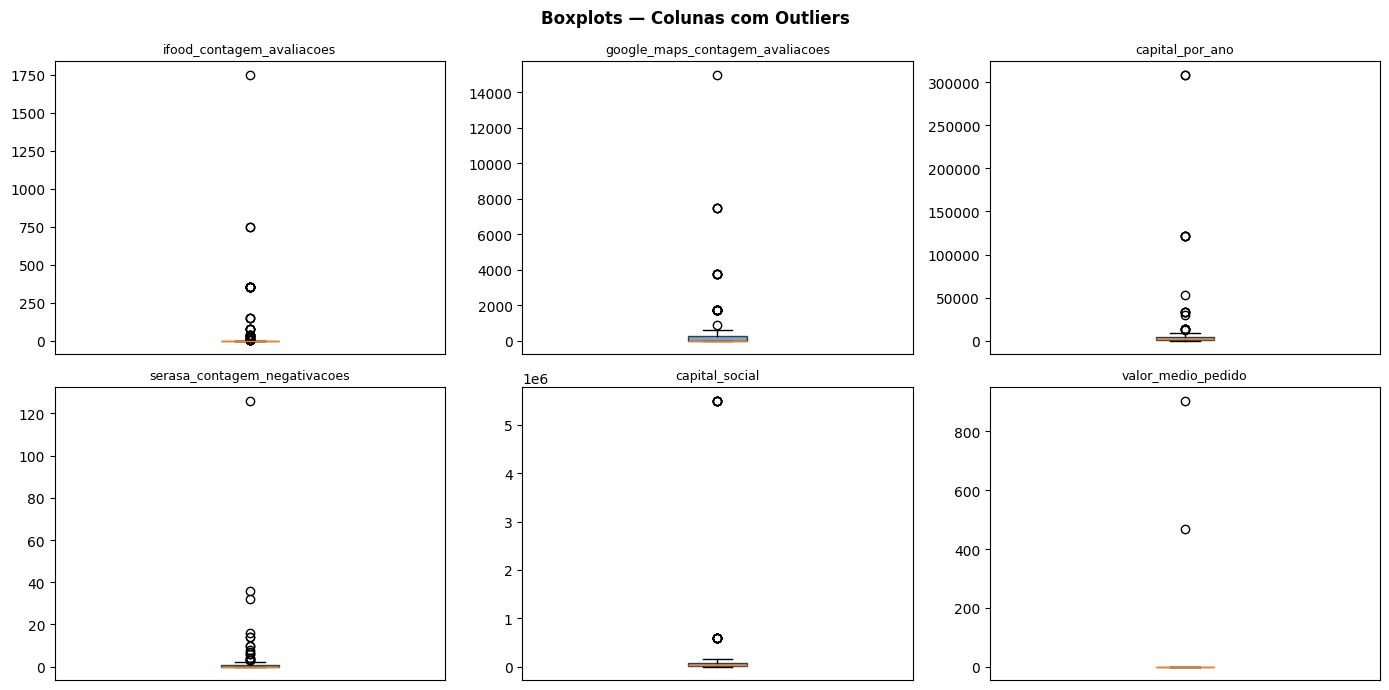

In [73]:
# Visualização dos boxplots das colunas com mais outliers
top_outlier_cols = df_outliers[df_outliers['n_outliers'] > 0]['coluna'].tolist()[:6]

if top_outlier_cols:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()
    for i, col in enumerate(top_outlier_cols):
        axes[i].boxplot(X_treino[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='steelblue', alpha=0.7))
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xticks([])
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Boxplots — Colunas com Outliers', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhuma coluna com outliers expressivos encontrada.')

#### Decisão sobre Outliers

Dado o contexto de negócio, **não serão removidos outliers** nesta etapa pelos seguintes motivos:

1. **Dataset pequeno (200 linhas)**: remoção de outliers reduziria ainda mais os dados disponíveis para treino.
2. **Outliers são informativos**: um `capital_social` muito alto ou `serasa_contagem_negativacoes` elevada pode ser exatamente o sinal discriminativo para prever inadimplência.
3. **Normalização posterior**: a padronização (seção 6) já minimiza o impacto dos outliers em algoritmos sensíveis à escala.
4. **Modelos robustos**: Random Forest e XGBoost são naturalmente resistentes a outliers.

### 5.3 Avaliação de Colunas com Baixa Variância

Colunas com variância muito baixa não contribuem para a separação das classes e podem prejudicar o modelo.

In [74]:
# Calcular variância das colunas numéricas
df_num = X_treino.select_dtypes(include=[np.number]).drop(columns=['inadimplente'], errors='ignore')

variancia = df_num.var().sort_values()

# Threshold: colunas com variância < 0.01 são candidatas a remoção
LIMIAR_VARIANCIA = 0.01
colunas_baixa_variancia = variancia[variancia < LIMIAR_VARIANCIA].index.tolist()

print(f'Colunas com variância < {LIMIAR_VARIANCIA}:')
if colunas_baixa_variancia:
    print(variancia[variancia < LIMIAR_VARIANCIA].to_string())
else:
    print('Nenhuma coluna com variância abaixo do limiar encontrada.')

print(f'\nVariância das 10 colunas com menor variância:')
print(variancia.head(10).round(6))

Colunas com variância < 0.01:
taxa_atraso                                  0.000037
atraso_medio                                 0.004944
municipio_FERNANDO DE NORONHA                0.006250
credor_impressão_e_gráficas                  0.006250
cnae_secao_R                                 0.006250
segmento_cliente_Atacarejo & Supermercado    0.006250
segmento_cliente_Saudável                    0.006250
municipio_CABO DE SANTO AGOSTINHO            0.006250
credor_energia                               0.006250
credor_diversos                              0.006250
municipio_HORIZONTE                          0.006250
credor_tecnologia_e_pagamentos               0.006250
municipio_EUSEBIO                            0.006250
segmento_cliente_Cozinha Industrial          0.006250
municipio_SAO LOURENCO DA MATA               0.006250
pedidos_com_atraso                           0.006250
cnae_secao_S                                 0.006250
tem_historico_atraso                         0.00625

In [75]:
# Remover colunas com variância abaixo do limiar (se existirem)
if colunas_baixa_variancia:
    # Verificar se são realmente pouco informativas
    print('Análise das colunas candidatas à remoção:')
    for col in colunas_baixa_variancia:
        print(f'  {col}: var={variancia[col]:.6f}, unique={X_treino[col].nunique()}, values={X_treino[col].unique()[:5]}')
    
    X_treino.drop(columns=colunas_baixa_variancia, inplace=True)
    print(f'\n{len(colunas_baixa_variancia)} coluna(s) removida(s) do Treino: {colunas_baixa_variancia}')
    #Removendo também as mesmas colunas do treino (apesar dele não ter visto os valores delas)
    X_teste.drop(columns=colunas_baixa_variancia, inplace=True, errors='ignore')
    print(f'\n{len(colunas_baixa_variancia)} coluna(s) removida(s) do Teste: {colunas_baixa_variancia}')
else:
    print('Nenhuma coluna removida por baixa variância.')

print(f'\nShape atual: {X_treino.shape}')
print(f'Shape atual: {X_teste.shape}')

Análise das colunas candidatas à remoção:
  taxa_atraso: var=0.000037, unique=2, values=[0.     0.0769]
  atraso_medio: var=0.004944, unique=3, values=[ 0.         -0.875       0.15384615]
  municipio_FERNANDO DE NORONHA: var=0.006250, unique=2, values=[0. 1.]
  credor_impressão_e_gráficas: var=0.006250, unique=2, values=[0 1]
  cnae_secao_R: var=0.006250, unique=2, values=[0. 1.]
  segmento_cliente_Atacarejo & Supermercado: var=0.006250, unique=2, values=[0. 1.]
  segmento_cliente_Saudável: var=0.006250, unique=2, values=[0. 1.]
  municipio_CABO DE SANTO AGOSTINHO: var=0.006250, unique=2, values=[0. 1.]
  credor_energia: var=0.006250, unique=2, values=[0 1]
  credor_diversos: var=0.006250, unique=2, values=[0 1]
  municipio_HORIZONTE: var=0.006250, unique=2, values=[0. 1.]
  credor_tecnologia_e_pagamentos: var=0.006250, unique=2, values=[0 1]
  municipio_EUSEBIO: var=0.006250, unique=2, values=[0. 1.]
  segmento_cliente_Cozinha Industrial: var=0.006250, unique=2, values=[0. 1.]
  muni

## 6. Padronização/Normalização das Variáveis Numéricas

A padronização é feita apenas no conjunto de treino para ajustar o scaler. O mesmo scaler é aplicado ao conjunto de teste, evitando leakage.

Usamos **StandardScaler** (média 0, desvio padrão 1), pois:
- Adequado para modelos lineares e SVM
- Random Forest e XGBoost não precisam, mas não são prejudicados

In [76]:
# Identificar colunas numericas continuas para escalar (excluir binárias)
# Heurística: colunas com mais de 2 valores únicos e não binárias
colunas_binarias = [c for c in X_treino.columns if X_treino[c].nunique() <= 2]
colunas_para_escalar = [c for c in X_treino.select_dtypes(include=[np.number]).columns
                        if c not in colunas_binarias]

print(f'Colunas binárias (não serão escaladas): {len(colunas_binarias)}')
print(f'Colunas a escalar: {len(colunas_para_escalar)}')
print(colunas_para_escalar)

Colunas binárias (não serão escaladas): 45
Colunas a escalar: 19
['capital_social', 'idade_cnpj', 'serasa_contagem_negativacoes', 'serasa_contagem_protestos', 'ifood_contagem_avaliacoes', 'ifood_faixa_preco', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'qtd_pedidos', 'valor_total_pedidos', 'valor_medio_pedido', 'valor_max_pedido', 'atraso_total', 'natureza_juridica_cod', 'cnae_divisao', 'score_serasa_negativo', 'presenca_digital', 'capital_por_ano', 'reputacao_google']


In [77]:
# Ajustar scaler apenas no treino — aplicar em treino e teste
scaler = StandardScaler()

X_treino_scaled = X_treino.copy()
X_teste_scaled  = X_teste.copy()

if colunas_para_escalar:
    X_treino_scaled[colunas_para_escalar] = scaler.fit_transform(X_treino[colunas_para_escalar])
    X_teste_scaled[colunas_para_escalar]  = scaler.transform(X_teste[colunas_para_escalar])

print('Padronização aplicada com StandardScaler.')
print('\nEstatísticas do treino após escalonamento (deve ter média ≈ 0):')
print(X_treino_scaled[colunas_para_escalar[:5]].describe().round(3))

Padronização aplicada com StandardScaler.

Estatísticas do treino após escalonamento (deve ter média ≈ 0):
       capital_social  idade_cnpj  serasa_contagem_negativacoes  \
count         160.000     160.000                       160.000   
mean            0.000      -0.000                         0.000   
std             1.003       1.003                         1.003   
min            -0.276      -1.856                        -0.198   
25%            -0.264      -0.770                        -0.198   
50%            -0.238      -0.770                        -0.198   
75%            -0.195       1.214                        -0.105   
max             5.023       1.214                        11.480   

       serasa_contagem_protestos  ifood_contagem_avaliacoes  
count                    160.000                    160.000  
mean                      -0.000                      0.000  
std                        1.003                      1.003  
min                       -0.229         

## 7. Salvando o Novo Dataset

Nesta seção será salvo o novo dataset, dividido em conjunto de teste e de treino

### 7.1 Salvamento do Dataset Completo Tratado

In [78]:
# Pasta e nome do arquivo de saida
pasta_saida = '../dados/tratados'
os.makedirs(pasta_saida, exist_ok=True)

# Dataset completo tratado (sem divisão)
#nome_completo = 'clientes_preprocessado.csv'
#df_clientes_tratado.to_csv(os.path.join(pasta_saida, nome_completo), index=False, encoding='utf-8-sig')
#print(f'Dataset completo salvo: {nome_completo}')
#print(f'  Dimensão: {df_clientes_tratado.shape[0]} linhas x {df_clientes_tratado.shape[1]} colunas')

# Conjuntos de treino e teste
df_treino_final = X_treino_scaled.copy()
df_treino_final['inadimplente'] = y_treino.values
df_treino_final.to_csv(os.path.join(pasta_saida, 'treino_preprocessado.csv'), index=False, encoding='utf-8-sig')

df_teste_final = X_teste_scaled.copy()
df_teste_final['inadimplente'] = y_teste.values
df_teste_final.to_csv(os.path.join(pasta_saida, 'teste_preprocessado.csv'), index=False, encoding='utf-8-sig')

print(f'\nConjunto de treino salvo: treino_preprocessado.csv ({df_treino_final.shape})')
print(f'Conjunto de teste salvo:  teste_preprocessado.csv ({df_teste_final.shape})')


Conjunto de treino salvo: treino_preprocessado.csv ((160, 65))
Conjunto de teste salvo:  teste_preprocessado.csv ((40, 65))


In [79]:
X_treino.info()

<class 'pandas.DataFrame'>
Index: 160 entries, 47 to 179
Data columns (total 64 columns):
 #   Column                                                                        Non-Null Count  Dtype  
---  ------                                                                        --------------  -----  
 0   capital_social                                                                160 non-null    float64
 1   idade_cnpj                                                                    160 non-null    float64
 2   serasa_contagem_negativacoes                                                  160 non-null    float64
 3   serasa_contagem_protestos                                                     160 non-null    float64
 4   serasa_socio_tem_negativacao                                                  160 non-null    float64
 5   ifood_contagem_avaliacoes                                                     160 non-null    float64
 6   ifood_faixa_preco                                

In [80]:
X_treino.head()

,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,ifood_faixa_preco,google_maps_avaliacao,google_maps_contagem_avaliacoes,google_maps_tem_website,...,credor_tecnologia,credor_telecomunicações,cnae_divisao,cnae_secao_G,cnae_secao_I,score_serasa_negativo,presenca_digital,capital_por_ano,ticket_medio_alto,reputacao_google
47,9000.0,6500.0,0.0,0.0,1.0,0.0,0,2.50,2.5,1.0,...,0,0,55,0.0,1.0,1.0,1,505.38,0,3.1319
175,40000.0,16500.0,0.0,0.0,0.0,0.0,0,0.00,3750.0,1.0,...,0,0,10,0.0,0.0,0.0,1,884.85,0,0.0000
31,9000.0,6500.0,0.0,0.0,1.0,0.0,0,0.00,0.0,0.0,...,0,0,56,0.0,1.0,1.0,0,505.38,0,0.0000
132,25000.0,6500.0,0.0,0.0,0.0,0.0,0,4.25,75.0,1.0,...,0,0,10,0.0,0.0,0.0,1,1403.85,0,18.4056
75,25000.0,6500.0,0.0,0.0,0.0,0.0,0,0.00,0.0,0.0,...,0,0,56,0.0,1.0,0.0,0,1403.85,0,0.0000


In [81]:
X_treino_scaled.head()

,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,ifood_faixa_preco,google_maps_avaliacao,google_maps_contagem_avaliacoes,google_maps_tem_website,...,credor_tecnologia,credor_telecomunicações,cnae_divisao,cnae_secao_G,cnae_secao_I,score_serasa_negativo,presenca_digital,capital_por_ano,ticket_medio_alto,reputacao_google
47,-0.267751,-0.770052,-0.198115,-0.228527,1.0,-0.285775,-0.530217,0.408270,-0.346650,1.0,...,0,0,0.637425,0.0,1.0,-0.158220,0.276104,-0.262432,0,-0.472249
175,-0.237879,1.213819,-0.198115,-0.228527,0.0,-0.285775,-0.530217,-0.805917,1.864298,1.0,...,0,0,-1.569047,0.0,0.0,-0.249283,0.276104,-0.252684,0,-0.726593
31,-0.267751,-0.770052,-0.198115,-0.228527,1.0,-0.285775,-0.530217,-0.805917,-0.348125,0.0,...,0,0,0.686458,0.0,1.0,-0.158220,-1.023207,-0.262432,0,-0.726593
132,-0.252333,-0.770052,-0.198115,-0.228527,0.0,-0.285775,-0.530217,1.258201,-0.303876,1.0,...,0,0,-1.569047,0.0,0.0,-0.249283,0.276104,-0.239353,0,0.768142
75,-0.252333,-0.770052,-0.198115,-0.228527,0.0,-0.285775,-0.530217,-0.805917,-0.348125,0.0,...,0,0,0.686458,0.0,1.0,-0.249283,-1.023207,-0.239353,0,-0.726593


## 8. Resumo Geral das Ativadades

In [82]:
print('=' * 70)
print('RESUMO — FASE 2: PRÉ-PROCESSAMENTO')
print('=' * 70)

print('\n✅ 1.2 Merge com dados de pedidos')
print('   Features: qtd_pedidos, valor_total, valor_medio, atraso_total, taxa_atraso...')

print('\n📊 TRANSFORMAÇÕES APLICADAS:')
print('\n✅ 2.1 Intervalos → Mediana do intervalo')
print('   Colunas tratadas: capital_social, idade_cnpj, ifood_contagem_avaliacoes,')
print('   google_maps_avaliacao, google_maps_contagem_avaliacoes')

print('\n✅ 2.2 Valores Nulos')
print('   Colunas de presença criadas: tem_google_maps, tem_ifood, tem_credores')
print('   Nulos preenchidos com 0 (ausência de dado = não tem cadastro)')

print('\n✅ 3 Variáveis Categóricas → Numéricas')
print('   • 3.1 Separação Treino/Teste')
print(f'   Estratégia: 80/20 com stratify na classe alvo')
print(f'   Random state: 42')
print('   • 3.2 Identificação das Variavéis Categóricas')
print('   • 3.3 ifood_faixa_preco: mapeamento ordinal ($=1 a $$$$$=5)')
print('   • 3.4 natureza_juridica: código numérico extraído')
print('   • 3.5 fonte_cliente: One-Hot Encoding')
print('   • 3.6 uf e municipio: One-Hot Encoding (drop_first=True)')
print('   • 3.7 segmento_cliente: Label Encoding')

print('\n✅ 4.1 serasa_credores (lista composta) → Colunas binárias por setor')
print('   Exemplo: credor_tecnologia, credor_financeiro, credor_saúde...')

print('\n✅ 4.2 CNAE → cnae_divisao (int) + cnae_secao (label encoded)')
print('   Seção CNAE identifica o grande setor econômico do estabelecimento')

print('\n✅ 5.1 Feature Engineering (Features derivadas criadas)')
print('   • score_serasa_negativo: combinação de negativações e protestos')
print('   • presenca_digital: índice de presença (iFood + Google Maps)')
print('   • capital_por_ano: capital social normalizado por tempo de empresa')
print('   • tem_historico_atraso: indicador binário de atraso histórico')
print('   • ticket_medio_alto: comparação com mediana do valor médio')
print('   • reputacao_google: índice combinado de nota e volume de avaliações')

print('\n✅ 5.2 Outliers analisados via IQR → mantidos (dataset pequeno + modelos robustos)')

print('\n✅ 5.3 Baixa variância avaliada → colunas quase constantes removidas')

print('\n✅ 6 StandardScaler ajustado no treino, aplicado no teste (sem leakage)')

print('\n✅ 7. Arquivos salvos em dados/tratados/')
print('   • treino_preprocessado.csv → treino escalado + target')
print('   • teste_preprocessado.csv → teste escalado + target')

# Estatísticas finais dinâmicas
n_features = X_treino_scaled.shape[1]
n_samples_train = X_treino_scaled.shape[0]
n_samples_test = X_teste_scaled.shape[0]
taxa_inadimplencia = y.mean() * 100
n_samples_inadimplentes = (y == 1).sum()
n_samples_adimplentes = (y == 0).sum()

print('\n' + '=' * 70)
print('📈 RESULTADO FINAL')
print('=' * 70)
print(f'\n🔢 Dimensões do Dataset:')
print(f'   Treino:  {n_samples_train} amostras × {n_features} features')
print(f'   Teste:   {n_samples_test} amostras × {n_features} features')
print(f'   Total:   {n_samples_train + n_samples_test} amostras')

print(f'\n📊 Distribuição da Classe Alvo (Inadimplência):')
print(f'   Adimplentes (0):      {n_samples_adimplentes:3d} amostras ({(n_samples_adimplentes/(len(y))*100):.1f}%)')
print(f'   Inadimplentes (1):    {n_samples_inadimplentes:3d} amostras ({taxa_inadimplencia:.1f}%)')
print(f'   Proporção (desbalanceamento): 1:{n_samples_adimplentes/max(n_samples_inadimplentes, 1):.1f}')

print(f'\n✨ Features para Modelagem: {n_features}')
print(f'   • Numéricas contínuas escaladas')
print(f'   • Variáveis binárias (presença, indicadores)')
print(f'   • Variáveis categóricas codificadas')

print('\n' + '=' * 70)


RESUMO — FASE 2: PRÉ-PROCESSAMENTO

✅ 1.2 Merge com dados de pedidos
   Features: qtd_pedidos, valor_total, valor_medio, atraso_total, taxa_atraso...

📊 TRANSFORMAÇÕES APLICADAS:

✅ 2.1 Intervalos → Mediana do intervalo
   Colunas tratadas: capital_social, idade_cnpj, ifood_contagem_avaliacoes,
   google_maps_avaliacao, google_maps_contagem_avaliacoes

✅ 2.2 Valores Nulos
   Colunas de presença criadas: tem_google_maps, tem_ifood, tem_credores
   Nulos preenchidos com 0 (ausência de dado = não tem cadastro)

✅ 3 Variáveis Categóricas → Numéricas
   • 3.1 Separação Treino/Teste
   Estratégia: 80/20 com stratify na classe alvo
   Random state: 42
   • 3.2 Identificação das Variavéis Categóricas
   • 3.3 ifood_faixa_preco: mapeamento ordinal ($=1 a $$$$$=5)
   • 3.4 natureza_juridica: código numérico extraído
   • 3.5 fonte_cliente: One-Hot Encoding
   • 3.6 uf e municipio: One-Hot Encoding (drop_first=True)
   • 3.7 segmento_cliente: Label Encoding

✅ 4.1 serasa_credores (lista composta)